# Impact of economic indicators on properties

## 1. Data Acquisition
In this section, we programmatically download the "Global Housing Market Analysis (2015-2024)" dataset.
By using `kagglehub`, we ensure that the analysis always runs on the latest available version of the data. 
We will then locate the CSV file within the downloaded path and load it into a Pandas DataFrame for processing.


In [2]:
# --- Loading Data using kagglehub ---
import kagglehub
import pandas as pd
import os

# 1. Download latest version of the dataset
path = kagglehub.dataset_download("atharvasoundankar/global-housing-market-analysis-2015-2024")

# 2. Automatically find and load the CSV file
files = os.listdir(path)
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

# 3. Create the main DataFrame
df_housing = pd.read_csv(full_path)

# Quick check of the data integrity
print(f"\nSuccessfully loaded: {csv_file}")
print(f"Total records: {len(df_housing)}")
display(df_housing.head())



Successfully loaded: global_housing_market_extended.csv
Total records: 200


,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


## 2. Initial Data Inspection
In this section, we examine the structure of the dataset based on the provided documentation. 
The goal is to ensure that all numerical indicators (like Interest Rates and GDP Growth) are correctly typed and to identify any missing information that could bias our analysis.

### Key Indicators:
*   **Target Variable:** `Average House Price ($)`
*   **Predictors:** `Mortgage Interest Rate (%)`, `GDP Growth Rate (%)`, `Unemployment Rate (%)`, `Household Income ($)`.


In [3]:
# --- Initial Data Inspection ---

# 1. Check data types and general info
print("--- Data Info ---")
print(df_housing.info())

# 2. Check for missing values (Critical for Data Cleaning)
print("\n--- Missing Values per Column ---")
missing_values = df_housing.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "No missing values found.")

# 3. Descriptive statistics for a sanity check
# This helps identify if values like 'Mortgage Rate' or 'GDP Growth' are within realistic ranges.
print("\n--- Descriptive Statistics ---")
display(df_housing.describe().T)

# 4. Check unique countries and time range
print(f"\nUnique Countries: {df_housing['Country'].nunique()}")
print(f"Time Period: {df_housing['Year'].min()} - {df_housing['Year'].max()}")


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                200 non-null    object 
 1   Year                   200 non-null    int64  
 2   House Price Index      200 non-null    float64
 3   Rent Index             200 non-null    float64
 4   Affordability Ratio    200 non-null    float64
 5   Mortgage Rate (%)      200 non-null    float64
 6   Inflation Rate (%)     200 non-null    float64
 7   GDP Growth (%)         200 non-null    float64
 8   Population Growth (%)  200 non-null    float64
 9   Urbanization Rate (%)  200 non-null    float64
 10  Construction Index     200 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 17.3+ KB
None

--- Missing Values per Column ---
No missing values found.

--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Year,200.0,2019.500000,2.879489,2015.000000,2017.000000,2019.500000,2022.000000,2024.000000
House Price Index,200.0,130.381022,28.752229,80.552212,104.142562,129.193653,157.127098,179.971767
Rent Index,200.0,83.048370,21.439858,50.354311,60.466671,83.721711,100.604665,119.855388
Affordability Ratio,200.0,7.237768,2.576085,3.041688,5.034207,7.375697,9.276196,11.879671
Mortgage Rate (%),200.0,4.150621,1.380222,1.537814,3.045278,4.329643,5.217706,6.485623
Inflation Rate (%),200.0,3.649756,1.881938,0.532110,1.939199,3.664625,5.261720,6.912349
GDP Growth (%),200.0,2.133722,2.413270,-1.921833,-0.095628,2.307548,4.272776,5.958931
Population Growth (%),200.0,0.722806,1.035691,-0.961391,-0.183320,0.722372,1.621317,2.497948
Urbanization Rate (%),200.0,74.769891,8.734246,60.172760,66.923842,75.100060,82.677430,89.788944
Construction Index,200.0,111.204257,24.309473,70.968678,90.182198,110.593807,133.780445,149.735748



Unique Countries: 20
Time Period: 2015 - 2024


## 3. Exploratory Data Analysis (EDA): Market Dynamics
After inspecting the raw data, we identified the correct indicators. We will now focus on the **House Price Index** as our primary metric for property value trends.

**Key Metrics for Analysis:**
*   **House Price Index:** Measures the change in residential property prices.
*   **Mortgage Rate (%):** The primary driver of borrowing costs.
*   **GDP Growth (%):** Indicator of overall economic health.


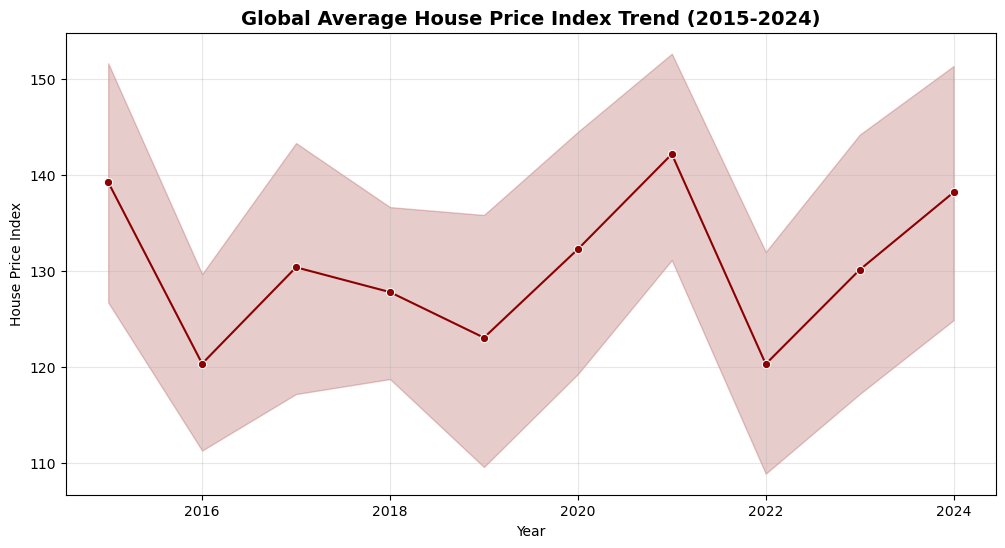

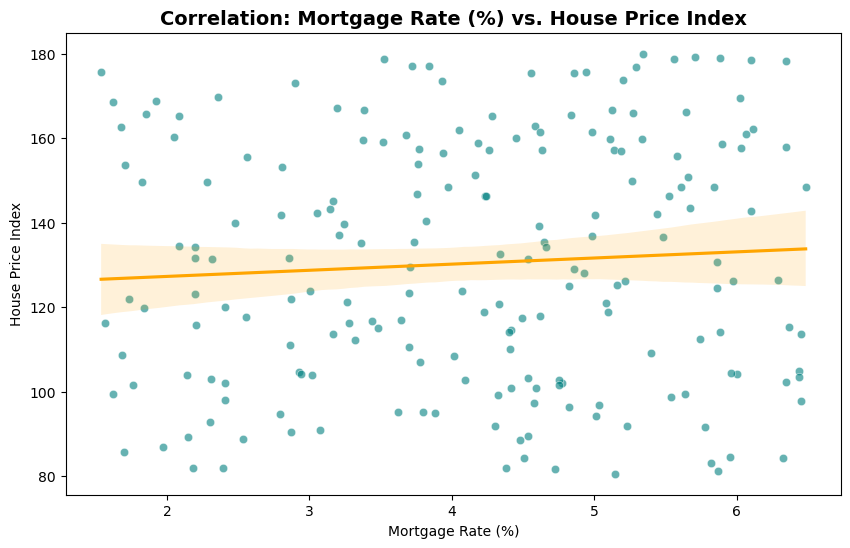

In [7]:
# --- EDA: Global Trends and Economic Impact ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Global Trend of House Price Index (2015-2024)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_housing, x='Year', y='House Price Index', marker='o', estimator='mean', color='darkred')
plt.title('Global Average House Price Index Trend (2015-2024)', fontsize=14, fontweight='bold')
plt.ylabel('House Price Index')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Relationship between Mortgage Rates and House Price Index
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_housing, x='Mortgage Rate (%)', y='House Price Index', alpha=0.6, color='teal')
sns.regplot(data=df_housing, x='Mortgage Rate (%)', y='House Price Index', scatter=False, color='orange')
plt.title('Correlation: Mortgage Rate (%) vs. House Price Index', fontsize=14, fontweight='bold')
plt.xlabel('Mortgage Rate (%)')
plt.ylabel('House Price Index')
plt.show()


## 4. Correlation Analysis: Identifying Key Price Drivers
To understand how different economic factors influence the housing market, we calculate the correlation matrix. 
This heatmap will help us identify which indicators, such as **Inflation**, **Urbanization**, or **Construction Index**, have the strongest linear relationship with the **House Price Index**.

*   **Positive Correlation:** As the indicator increases, house prices tend to rise.
*   **Negative Correlation:** As the indicator increases, house prices tend to decrease.

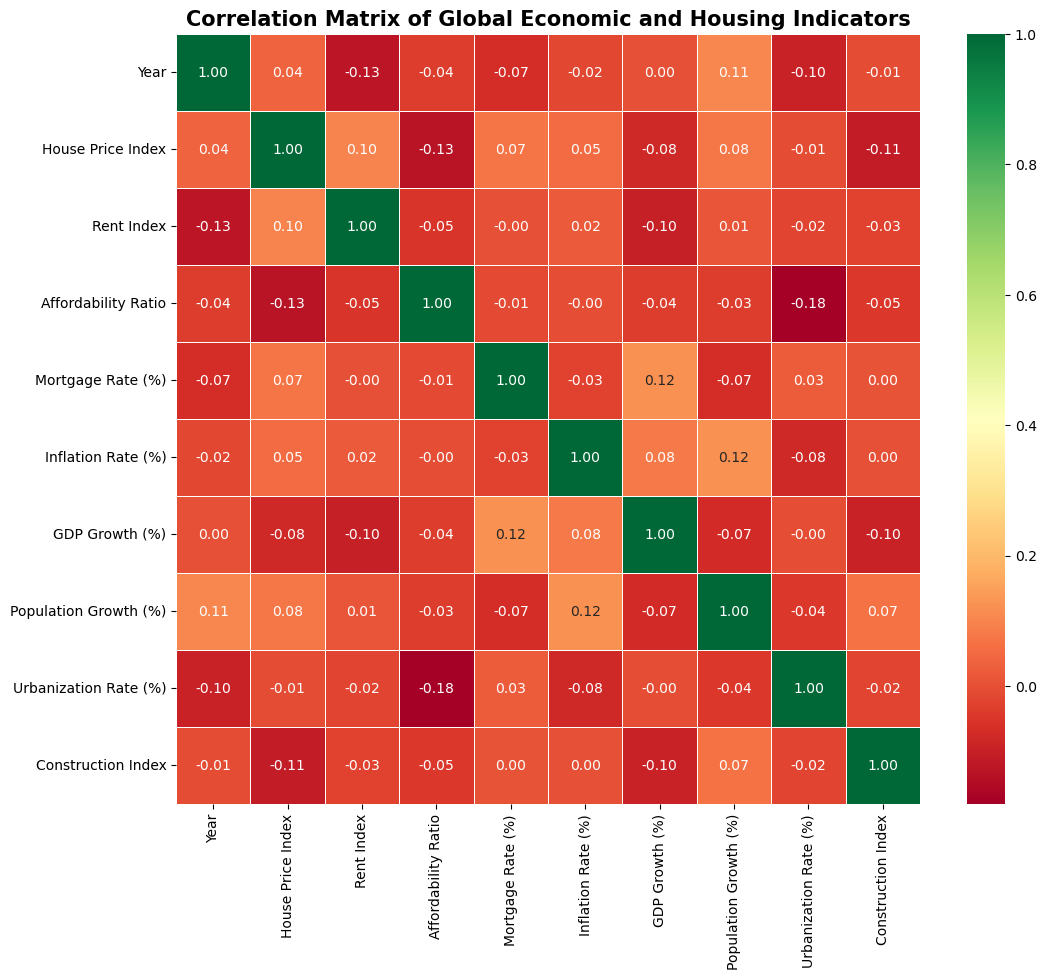

Correlation of House Price Index with other indicators:
House Price Index        1.000000
Rent Index               0.098280
Population Growth (%)    0.076943
Mortgage Rate (%)        0.069741
Inflation Rate (%)       0.050327
Year                     0.036894
Urbanization Rate (%)   -0.005663
GDP Growth (%)          -0.080581
Construction Index      -0.108723
Affordability Ratio     -0.132869
Name: House Price Index, dtype: float64


In [9]:
# --- Statistical Analysis: Correlation Heatmap ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only numerical columns for correlation
# We use np.number to ensure all float and int columns are captured
numerical_df = df_housing.select_dtypes(include=[np.number])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numerical_df.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(12, 10))
# 'RdYlGn' color map: Green is positive, Red is negative correlation
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of Global Economic and Housing Indicators', fontsize=15, fontweight='bold')
plt.show()

# 4. Extracting specific insights for House Price Index
print("Correlation of House Price Index with other indicators:")
print(corr_matrix['House Price Index'].sort_values(ascending=False))


## 5. Integrating the Second Data Source: Financial Market Performance
To comply with the project requirements for multiple data sources, we introduce the **S&P 500 Index (^GSPC)**. 
The goal is to determine if the stock market performance correlates with the global housing market, potentially acting as a leading indicator or a parallel asset class.

**Steps:**
1. Fetch historical annual closing prices for S&P 500 (2015-2024).
2. Calculate annual returns.
3. Merge the financial data with the existing housing dataset.


In [10]:
# --- Fetching Second Data Source: S&P 500 Index ---
import yfinance as yf
import pandas as pd

# 1. Download S&P 500 historical data
print("Fetching S&P 500 data from Yahoo Finance...")
sp500 = yf.download("^GSPC", start="2015-01-01", end="2024-12-31", interval="1d")

# 2. Handle MultiIndex columns (common in newer yfinance versions)
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

# 3. Resample to annual data (taking the last trading day of each year)
# Note: 'YE' is the new alias for 'A' in recent pandas versions
sp500_annual = sp500['Close'].resample('YE').last().reset_index()
sp500_annual['Year'] = sp500_annual['Date'].dt.year

# 4. Rename columns for clarity
sp500_annual.rename(columns={'Close': 'SP500_Close'}, inplace=True)

# 5. Merge with the main housing dataset
df_combined = pd.merge(df_housing, sp500_annual[['Year', 'SP500_Close']], on='Year', how='left')

print("\nData merging complete. Preview of combined dataset:")
display(df_combined[['Country', 'Year', 'House Price Index', 'SP500_Close']].head())


Fetching S&P 500 data from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed



Data merging complete. Preview of combined dataset:


,Country,Year,House Price Index,SP500_Close
0,USA,2015,117.454012,2043.939941
1,USA,2016,150.807258,2238.830078
2,USA,2017,123.194502,2673.610107
3,USA,2018,131.423444,2506.850098
4,USA,2019,110.461377,3230.780029


## 6. Comparative Analysis: Real Estate vs. Stock Market Trends
In this section, we compare the global **House Price Index** with the **S&P 500** performance from 2015 to 2024. 
By using a dual-axis line chart, we can observe if market cycles in equity (stocks) coincide with cycles in the housing market. 

**Key Questions:**
*   Did the 2020-2021 liquidity surge affect both markets equally?
*   Is there a visible lag between stock market movements and housing price adjustments?


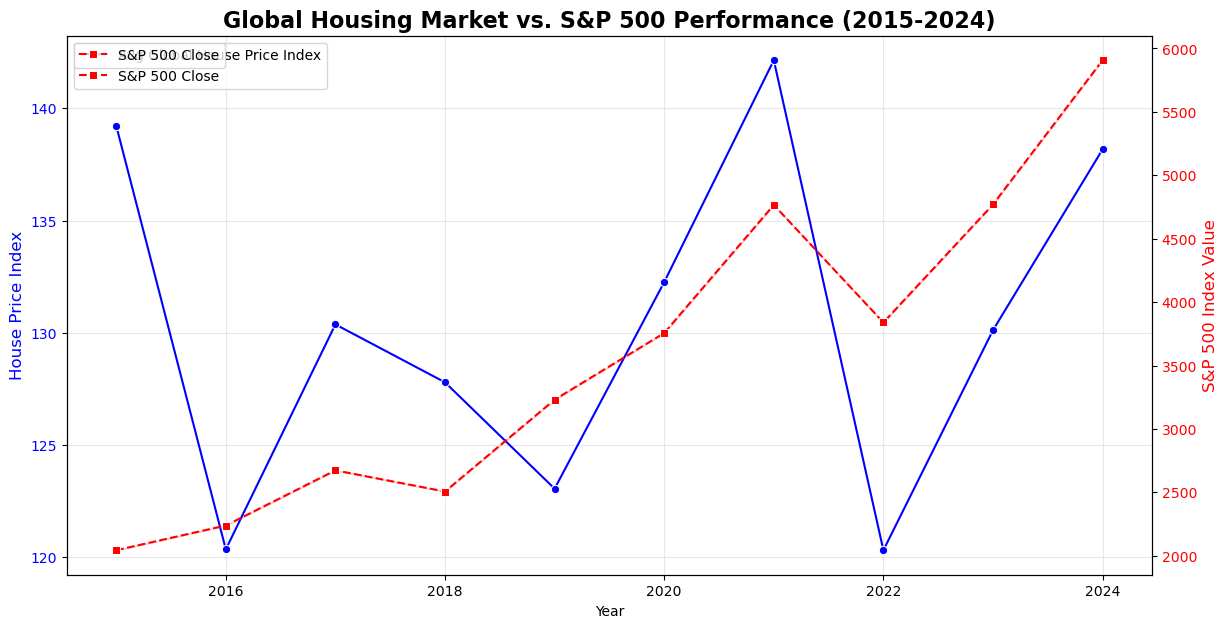

Pearson Correlation between Housing Index and S&P 500: 0.3896


In [11]:
# --- Visualization: Housing Index vs. S&P 500 ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data: Calculate the mean global House Price Index per year
annual_housing_mean = df_combined.groupby('Year')['House Price Index'].mean().reset_index()

# 2. Create the plot with two y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary Axis: House Price Index
sns.lineplot(data=annual_housing_mean, x='Year', y='House Price Index', ax=ax1, 
             color='blue', marker='o', label='Avg Global House Price Index')
ax1.set_ylabel('House Price Index', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Secondary Axis: S&P 500
ax2 = ax1.twinx()
sns.lineplot(data=df_combined.sort_values('Year'), x='Year', y='SP500_Close', ax=ax2, 
             color='red', marker='s', linestyle='--', label='S&P 500 Close')
ax2.set_ylabel('S&P 500 Index Value', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# Title and Legend
plt.title('Global Housing Market vs. S&P 500 Performance (2015-2024)', fontsize=16, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

# 3. Calculate Correlation between the two
correlation = annual_housing_mean['House Price Index'].corr(sp500_annual['SP500_Close'])
print(f"Pearson Correlation between Housing Index and S&P 500: {correlation:.4f}")
